<a href="https://colab.research.google.com/github/sebastianquintanam/dataexperience-final-project/blob/main/notebooks/Etapa1_Preparacion_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final DataXperience## Etapa 1: Preparación de datos
**Dataset:** Laptop Price (Kaggle)

**Hecho por:** Brayan Felipe Alvarez Nieto

En esta primera parte elegimos el conjunto de datos, revisamos en qué estado viene y lo dejamos listo para poder analizarlo.

## 1.1 ¿Por qué este dataset?
  
Escogimos un dataset de precios de portátiles que cuenta con 1.303 equipos y sus respectivas especificaciones técnicas, como marca, procesador, memoria RAM, almacenamiento, pantalla, peso y precio. Lo seleccionamos porque contiene suficiente información para aplicar los conocimientos adquiridos a lo largo del curso y realizar diferentes procesos de análisis y tratamiento de datos. Además, tenemos cierto conocimiento sobre las características de los equipos presentados, lo que nos permite interpretar los datos de una manera más sencilla y comprender mejor los resultados obtenidos.

  
La pregunta que queremos responder es: ¿qué características hacen que un portátil sea más caro, y se puede predecir el precio a partir de sus especificaciones?

## 1.2 Cargamos las librerías y el archivo

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('laptop_price.csv', encoding='latin-1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


El archivo hay que leerlo con `encoding='latin-1'`. Con el encoding normal daba error porque algunos nombres de producto tienen tildes.

## 1.3 ¿Cómo vienen los datos?

Antes de tocar nada, miramos qué tenemos: cuántas filas, qué tipo es cada columna,si hay datos faltantes y si hay filas repetidas.

In [14]:
print("Dimensiones:", df.shape)
print("\n--- Tipos de dato ---")
print(df.dtypes)
print("\n--- Nulos por columna ---")
print(df.isnull().sum())
print("\n--- Filas duplicadas ---")
print(df.duplicated().sum())
print("\n--- Duplicadas sin contar el ID ---")
print(df.drop(columns=['laptop_ID']).duplicated().sum())

Dimensiones: (1303, 13)

--- Tipos de dato ---
laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

--- Nulos por columna ---
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

--- Filas duplicadas ---
0

--- Duplicadas sin contar el ID ---
28


### Lo que encontramos

No hay nulos, o sea que por ese lado el dataset viene bien. Pero el problema
es otro: casi todas las columnas son de tipo `object`, o sea texto, incluso las que
deberían ser números.

Por ejemplo:

- `Ram` dice `"8GB"` en vez de `8`
- `Weight` dice `"1.37kg"` en vez de `1.37`
- `Memory` dice cosas como `"128GB SSD +  1TB HDD"`
- `ScreenResolution` mete el tipo de panel, si es táctil y la resolución, todo junto
- `Cpu` y `Gpu` traen el modelo exacto, que es demasiado específico

Así como está no podemos ni sacar el promedio de la RAM. Entonces la limpieza de este
proyecto no es rellenar huecos, es convertir todo ese texto en números y categorías
que sí sirvan.

Sobre las filas duplicadas: contando el laptop_ID no hay ninguna, pero al ignorarlo aparecen 28 filas repetidas. Las revisamos y son equipos con exactamente las mismas especificaciones y el mismo precio, por ejemplo tres Acer de 15.6 pulgadas a 289 euros.

Decidimos no eliminarlas. No parecen errores de captura sino el mismo modelo listado varias veces en el catálogo, que es información real del mercado: si un modelo se repite es porque hay varias unidades a la venta. Borrarlas sesgaría el análisis hacia los equipos raros. Después de agrupar categorías el número sube a 30, porque dos equipos que se diferenciaban solo por el sistema operativo quedan idénticos al agruparlos.

## 1.4 Limpieza

### 1.4.1 Ram y Weight

Son números con la unidad pegada. Quitamos el "GB" y el "kg" y ya.

In [15]:
df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)
df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

print(df[['Ram', 'Ram_GB', 'Weight', 'Weight_kg']].head())

    Ram  Ram_GB  Weight  Weight_kg
0   8GB       8  1.37kg       1.37
1   8GB       8  1.34kg       1.34
2   8GB       8  1.86kg       1.86
3  16GB      16  1.83kg       1.83
4   8GB       8  1.37kg       1.37


### 1.4.2 ScreenResolution

Esta columna trae tres cosas mezcladas: si el panel es IPS, si la pantalla es táctil,
y la resolución. Las separamos en columnas distintas.

Además calculamos el PPI (píxeles por pulgada). Lo hicimos porque dos portátiles de
15 pulgadas pueden tener pantallas muy distintas: uno a 1366x768 y otro a 1920x1080.
El tamaño solo no dice nada de la calidad, el PPI sí.

In [16]:
sr = df['ScreenResolution']

df['Touchscreen'] = sr.str.contains('Touchscreen').astype(int)
df['IPS'] = sr.str.contains('IPS').astype(int)

# sacamos los dos números de la resolución (ej: 1920x1080)
res = sr.str.extract(r'(\d+)x(\d+)').astype(int)
df['Res_X'] = res[0]
df['Res_Y'] = res[1]

# PPI = diagonal en píxeles / diagonal en pulgadas
df['PPI'] = np.sqrt(df['Res_X']**2 + df['Res_Y']**2) / df['Inches']

print(df[['ScreenResolution', 'Touchscreen', 'IPS', 'Res_X', 'Res_Y', 'PPI']].head())

                     ScreenResolution  Touchscreen  IPS  Res_X  Res_Y  \
0  IPS Panel Retina Display 2560x1600            0    1   2560   1600   
1                            1440x900            0    0   1440    900   
2                   Full HD 1920x1080            0    0   1920   1080   
3  IPS Panel Retina Display 2880x1800            0    1   2880   1800   
4  IPS Panel Retina Display 2560x1600            0    1   2560   1600   

          PPI  
0  226.983005  
1  127.677940  
2  141.211998  
3  220.534624  
4  226.983005  


### 1.4.3 Memory

Esta es la más enredada. Tiene tres problemas al tiempo:

1. Unas capacidades están en GB y otras en TB
2. Hay varios tipos de disco: SSD, HDD, Flash Storage e Hybrid
3. Algunos equipos traen dos discos, separados con un `+`

Lo que hicimos fue pasar todo a GB y crear una columna por cada tipo de disco. Así un
portátil con SSD de 128GB y disco duro de 1TB queda bien representado, con su capacidad
en la columna que le corresponde.

In [17]:
import re

def a_gigas(texto):
    """Saca la capacidad en GB de un texto tipo '128GB SSD' o '1.0TB HDD'."""
    m = re.search(r'([\d\.]+)\s*(TB|GB)', texto)
    if not m:
        return 0.0
    valor = float(m.group(1))
    if m.group(2) == 'TB':
        valor = valor * 1000   # 1TB = 1000GB
    return valor

# separamos los equipos que traen dos discos
partes = df['Memory'].str.split('+', n=1, expand=True)
if partes.shape[1] == 1:
    partes[1] = None

disco1 = partes[0].fillna('').str.strip()
disco2 = partes[1].fillna('').str.strip()

cap1 = disco1.apply(a_gigas)
cap2 = disco2.apply(a_gigas)

# cada capacidad va a la columna del tipo de disco que le corresponde
for tipo in ['SSD', 'HDD', 'Flash Storage', 'Hybrid']:
    col = tipo.replace(' ', '_') + '_GB'
    df[col] = cap1 * disco1.str.contains(tipo) + cap2 * disco2.str.contains(tipo)

print(df[['Memory', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].head(10))

                Memory  SSD_GB  HDD_GB  Flash_Storage_GB  Hybrid_GB
0            128GB SSD   128.0     0.0               0.0        0.0
1  128GB Flash Storage     0.0     0.0             128.0        0.0
2            256GB SSD   256.0     0.0               0.0        0.0
3            512GB SSD   512.0     0.0               0.0        0.0
4            256GB SSD   256.0     0.0               0.0        0.0
5            500GB HDD     0.0   500.0               0.0        0.0
6  256GB Flash Storage     0.0     0.0             256.0        0.0
7  256GB Flash Storage     0.0     0.0             256.0        0.0
8            512GB SSD   512.0     0.0               0.0        0.0
9            256GB SSD   256.0     0.0               0.0        0.0


In [18]:
# revisamos que no se nos haya escapado ningún caso raro
total = df[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']].sum(axis=1)
print("Equipos que quedaron en 0 de almacenamiento:", (total == 0).sum())

print("\nCuántos equipos tienen cada tipo de disco:")
print((df[['SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB']] > 0).sum())

Equipos que quedaron en 0 de almacenamiento: 0

Cuántos equipos tienen cada tipo de disco:
SSD_GB              843
HDD_GB              576
Flash_Storage_GB     75
Hybrid_GB            12
dtype: int64


### 1.4.4 Cpu y Gpu

`Cpu` trae el modelo completo del procesador, tan específico que hay modelos que aparecen
una sola vez en todo el dataset. Eso no sirve para agrupar. Nos quedamos con la gama
(Intel Core i5, Intel Core i7, etc.) y de la tarjeta gráfica solo con la marca.

Después de extraer la gama quedaban 40 categorías distintas, y 14 de ellas tenían un solo equipo. Con tan pocos casos no aportan nada y solo ensucian el análisis, así que agrupamos en "Otro" las que tienen menos de 10 equipos. Quedamos con 8 categorías y solo 79 equipos (6%) caen en "Otro".

In [19]:
df['Cpu_gama'] = df['Cpu'].str.split().str[:3].str.join(' ')
df['Gpu_marca'] = df['Gpu'].str.split().str[0]

print("Categorías de CPU antes de agrupar:", df['Cpu_gama'].nunique())

# hay 40 gamas distintas y muchas aparecen en 1 o 2 equipos,
# así que juntamos en "Otro" las que tengan menos de 10
conteo = df['Cpu_gama'].value_counts()
frecuentes = conteo[conteo >= 10].index
df['Cpu_gama'] = df['Cpu_gama'].where(df['Cpu_gama'].isin(frecuentes), 'Otro')

print("Después de agrupar:", df['Cpu_gama'].nunique())
print()
print(df['Cpu_gama'].value_counts())
print("\nMarcas de tarjeta gráfica:")
print(df['Gpu_marca'].value_counts())

Categorías de CPU antes de agrupar: 40
Después de agrupar: 8

Cpu_gama
Intel Core i7         527
Intel Core i5         423
Intel Core i3         136
Intel Celeron Dual     80
Otro                   79
Intel Pentium Quad     27
Intel Core M           19
AMD A9-Series 9420     12
Name: count, dtype: int64

Marcas de tarjeta gráfica:
Gpu_marca
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


### 1.4.5 OpSys

Hay nueve sistemas operativos distintos, pero varios tienen dos o tres equipos nomás
(Android, Chrome OS, Windows 10 S). Con tan pocos casos no se puede concluir nada,
así que los agrupamos en cuatro.

In [20]:
print("Antes:")
print(df['OpSys'].value_counts())

def agrupar_so(x):
    if x in ['Windows 10', 'Windows 7', 'Windows 10 S']:
        return 'Windows'
    elif x in ['macOS', 'Mac OS X']:
        return 'Mac'
    elif x == 'Linux':
        return 'Linux'
    else:
        return 'Otro'

df['SO'] = df['OpSys'].apply(agrupar_so)

print("\nDespués:")
print(df['SO'].value_counts())

Antes:
OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

Después:
SO
Windows    1125
Otro         95
Linux        62
Mac          21
Name: count, dtype: int64


## 1.5 Armamos el dataset limpio

Nos quedamos con las columnas nuevas y botamos las originales que ya procesamos.
También quitamos `laptop_ID`, que es solo un consecutivo y no aporta nada.

In [21]:
columnas = [
    'Company', 'TypeName', 'Inches', 'Ram_GB', 'Weight_kg',
    'Touchscreen', 'IPS', 'Res_X', 'Res_Y', 'PPI',
    'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB',
    'Cpu_gama', 'Gpu_marca', 'SO', 'Price_euros'
]

df_limpio = df[columnas].copy()

print("Tamaño final:", df_limpio.shape)
print("\n--- Tipos de dato ---")
print(df_limpio.dtypes)
print("\nNulos:", df_limpio.isnull().sum().sum())
df_limpio.head()

Tamaño final: (1303, 18)

--- Tipos de dato ---
Company              object
TypeName             object
Inches              float64
Ram_GB                int64
Weight_kg           float64
Touchscreen           int64
IPS                   int64
Res_X                 int64
Res_Y                 int64
PPI                 float64
SSD_GB              float64
HDD_GB              float64
Flash_Storage_GB    float64
Hybrid_GB           float64
Cpu_gama             object
Gpu_marca            object
SO                   object
Price_euros         float64
dtype: object

Nulos: 0


,Company,TypeName,Inches,Ram_GB,Weight_kg,Touchscreen,IPS,Res_X,Res_Y,PPI,SSD_GB,HDD_GB,Flash_Storage_GB,Hybrid_GB,Cpu_gama,Gpu_marca,SO,Price_euros
0,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,128.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1339.69
1,Apple,Ultrabook,13.3,8,1.34,0,0,1440,900,127.677940,0.0,0.0,128.0,0.0,Intel Core i5,Intel,Mac,898.94
2,HP,Notebook,15.6,8,1.86,0,0,1920,1080,141.211998,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Otro,575.00
3,Apple,Ultrabook,15.4,16,1.83,0,1,2880,1800,220.534624,512.0,0.0,0.0,0.0,Intel Core i7,AMD,Mac,2537.45
4,Apple,Ultrabook,13.3,8,1.37,0,1,2560,1600,226.983005,256.0,0.0,0.0,0.0,Intel Core i5,Intel,Mac,1803.60


## 1.6 Un primer vistazo

Antes de pasarle esto al análisis estadístico, miramos rápido cómo se ven los datos.

In [22]:
print(df_limpio.describe().T)

                   count         mean         std          min          25%  \
Inches            1303.0    15.017191    1.426304    10.100000    14.000000   
Ram_GB            1303.0     8.382195    5.084665     2.000000     4.000000   
Weight_kg         1303.0     2.038734    0.665475     0.690000     1.500000   
Touchscreen       1303.0     0.147352    0.354593     0.000000     0.000000   
IPS               1303.0     0.280123    0.449231     0.000000     0.000000   
Res_X             1303.0  1894.784344  494.641028  1366.000000  1600.000000   
Res_Y             1303.0  1070.830391  284.519410   768.000000   900.000000   
PPI               1303.0   146.635987   43.121345    90.583402   127.335675   
SSD_GB            1303.0   183.732924  186.966903     0.000000     0.000000   
HDD_GB            1303.0   413.783576  515.818779     0.000000     0.000000   
Flash_Storage_GB  1303.0     4.555641   30.274090     0.000000     0.000000   
Hybrid_GB         1303.0     8.831926   92.567185   

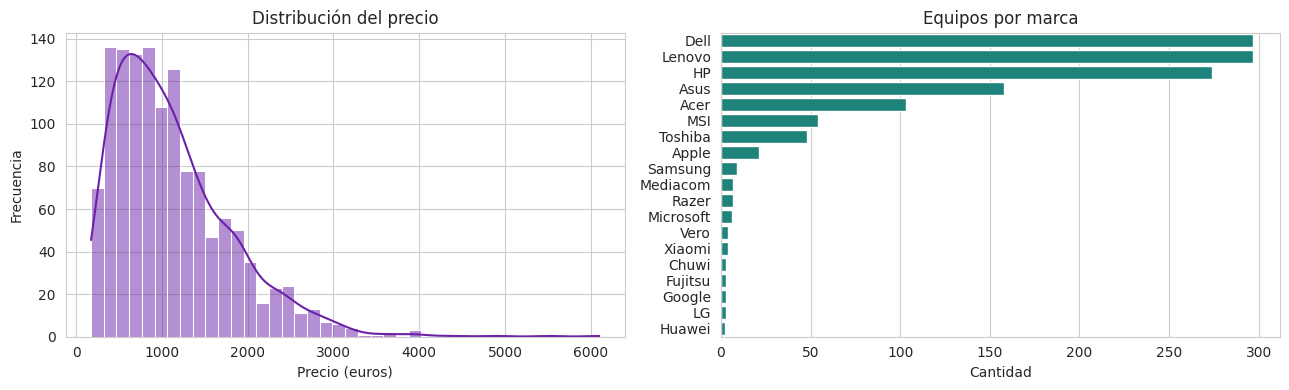

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_limpio['Price_euros'], bins=40, kde=True, ax=axes[0], color='#6B21A8')
axes[0].set_title('Distribución del precio')
axes[0].set_xlabel('Precio (euros)')
axes[0].set_ylabel('Frecuencia')

orden = df_limpio['Company'].value_counts().index
sns.countplot(y='Company', data=df_limpio, order=orden, ax=axes[1], color='#0D9488')
axes[1].set_title('Equipos por marca')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Se nota que el precio está sesgado hacia la derecha: la mayoría de equipos son de gama
media y hay unos pocos muy caros que estiran la cola. Esto hay que tenerlo en cuenta en
la Etapa 2, porque cuando la distribución es así la mediana representa mejor el valor
típico que el promedio.

## 1.7 Guardamos el archivo limpio

Este CSV es con el que van a trabajar las etapas 2 y 3.

In [24]:
df_limpio.to_csv('laptop_price_limpio.csv', index=False)
print("Listo:", len(df_limpio), "filas y", df_limpio.shape[1], "columnas")

Listo: 1303 filas y 18 columnas


## Resumen de lo que hicimos

Empezamos con 13 columnas, de las cuales 10 eran texto sin procesar, y terminamos con 18
columnas utilizables. No perdimos ningún registro, los 1.303 equipos siguen ahí.

Lo que se hizo en cada columna:

- **Ram, Weight:** quitamos la unidad y las volvimos números
- **ScreenResolution:** la partimos en 5 columnas (IPS, táctil, ancho, alto, PPI)
- **Memory:** normalizamos las unidades y la separamos por tipo de disco
- **Cpu, Gpu:** nos quedamos con la gama y la marca
- **OpSys:** agrupamos de 9 categorías a 4